In [20]:
import math
import numpy as np
import matplotlib.pyplot as plt


# Define physical constant 
q = 1.602192e-19                # Elementary charge
epsilon0 = 8.854187817e-12      # Vaccum permittibity
nint = 1e10                     # Intrinsic carrier concentration
kB = 1.38065e-23                # Boltzmann constant
T = 300.0                       # Temperature
VT = kB*T/q                     # Thermal Voltage  

# Define Simulation variable  
a = 6e-9                        # Silicon Thickness  
tox = 0.5e-9                    # Oxide Thickness  
N = 120                         # Number of grid points 
l0 = a/N                        # Grid Spacing
iox = round(tox/l0)             # Oxide region index  
interface1 = iox                # Start of Silicon region  
interface2 = N-iox              # End of Silicon region

epsilon_si = 11.7               # Silicon Permittibity
epsilon_ox = 3.9                # Oxide Permittibity  
Ndop = -1e24                    # Dopant Concentration  

# Position vector  
x = np.arange(N+1)* a / N       # (N+1) Grid points 0 to a

x

array([0.00e+00, 5.00e-11, 1.00e-10, 1.50e-10, 2.00e-10, 2.50e-10,
       3.00e-10, 3.50e-10, 4.00e-10, 4.50e-10, 5.00e-10, 5.50e-10,
       6.00e-10, 6.50e-10, 7.00e-10, 7.50e-10, 8.00e-10, 8.50e-10,
       9.00e-10, 9.50e-10, 1.00e-09, 1.05e-09, 1.10e-09, 1.15e-09,
       1.20e-09, 1.25e-09, 1.30e-09, 1.35e-09, 1.40e-09, 1.45e-09,
       1.50e-09, 1.55e-09, 1.60e-09, 1.65e-09, 1.70e-09, 1.75e-09,
       1.80e-09, 1.85e-09, 1.90e-09, 1.95e-09, 2.00e-09, 2.05e-09,
       2.10e-09, 2.15e-09, 2.20e-09, 2.25e-09, 2.30e-09, 2.35e-09,
       2.40e-09, 2.45e-09, 2.50e-09, 2.55e-09, 2.60e-09, 2.65e-09,
       2.70e-09, 2.75e-09, 2.80e-09, 2.85e-09, 2.90e-09, 2.95e-09,
       3.00e-09, 3.05e-09, 3.10e-09, 3.15e-09, 3.20e-09, 3.25e-09,
       3.30e-09, 3.35e-09, 3.40e-09, 3.45e-09, 3.50e-09, 3.55e-09,
       3.60e-09, 3.65e-09, 3.70e-09, 3.75e-09, 3.80e-09, 3.85e-09,
       3.90e-09, 3.95e-09, 4.00e-09, 4.05e-09, 4.10e-09, 4.15e-09,
       4.20e-09, 4.25e-09, 4.30e-09, 4.35e-09, 4.40e-09, 4.45e

In [21]:
# Initialize arrays  
phi = np.zeros( (N+1, 1  ) )        # Potential array
hole = np.zeros( (N+1, 1  ) )       # Hole density array
elec = np.zeros( (N+1, 1  ) )       # Electron density array  

# Intialize matrix & vector for solving Ax = b
A = np.zeros( (N+1, N+1) )          
b = np.zeros( (N+1, 1  ) )

In [22]:
# Newton-Raphson Iteration loop  
for inewton in range(1,10):

    # Linear Possion Equation (Descretized form)
    for ii in range(1,N):    
        epsilon_l = epsilon_ox
        epsilon_r = epsilon_ox

        # Permittibity Decision (Inside : Silicon, Outside : Oxide)
        if ii>=interface1+1 and ii<=interface2:
            epsilon_l = epsilon_si
        if ii>=interface1 and ii<=interface2-1:
            epsilon_r = epsilon_si    

        # Descretize Possion Equation 
        b[ii] = epsilon_r*(phi[ii+1]-phi[ii])-epsilon_l*(phi[ii]-phi[ii-1])
        # Generate Laplacian matrix  
        A[ii,ii-1] = epsilon_l
        A[ii,ii  ] = -epsilon_l-epsilon_r
        A[ii,ii+1] = epsilon_r

    # Non-linear Possion Equation 
    for ii in range(interface1,interface2+1):
        control = 1.0
        if ii==interface1 or ii==interface2:
            control = 0.5
        # Hole & Electron Density Equation using Thermal Volgage  
        hole[ii] = nint*math.exp(-phi[ii]/VT)
        elec[ii] = nint*math.exp( phi[ii]/VT)

        # Poisson Equation  
        b[ii] = b[ii] + q*(hole[ii]-elec[ii]+Ndop)/epsilon0*l0*l0*control
        # Jacobian Matrix  
        A[ii,ii] = A[ii,ii] - q*(hole[ii]+elec[ii])/VT/epsilon0*l0*l0*control

    # Boundary Condition  
    b[0] = phi[0] - 0.33374
    A[0,0] = 1
    b[N] = phi[N] - 0.33374
    A[N,N] = 1

    # Linear system solving & Update Potential value
    update = np.linalg.solve(A, b)
    phi = phi - update

    print(f"Iter{inewton} : phi = {phi}")

Iter1 : phi = [[0.33374   ]
 [0.33316002]
 [0.33258004]
 [0.33200007]
 [0.33142009]
 [0.33084011]
 [0.33026013]
 [0.32968016]
 [0.32910018]
 [0.3285202 ]
 [0.32794022]
 [0.32774883]
 [0.32756131]
 [0.32737765]
 [0.32719785]
 [0.32702193]
 [0.32684987]
 [0.32668167]
 [0.32651735]
 [0.32635688]
 [0.32620029]
 [0.32604756]
 [0.3258987 ]
 [0.32575371]
 [0.32561258]
 [0.32547532]
 [0.32534192]
 [0.3252124 ]
 [0.32508673]
 [0.32496494]
 [0.32484701]
 [0.32473295]
 [0.32462275]
 [0.32451642]
 [0.32441396]
 [0.32431536]
 [0.32422063]
 [0.32412977]
 [0.32404277]
 [0.32395964]
 [0.32388038]
 [0.32380498]
 [0.32373345]
 [0.32366579]
 [0.32360199]
 [0.32354206]
 [0.323486  ]
 [0.3234338 ]
 [0.32338547]
 [0.323341  ]
 [0.3233004 ]
 [0.32326367]
 [0.32323081]
 [0.32320181]
 [0.32317667]
 [0.32315541]
 [0.32313801]
 [0.32312448]
 [0.32311481]
 [0.32310901]
 [0.32310708]
 [0.32310901]
 [0.32311481]
 [0.32312448]
 [0.32313801]
 [0.32315541]
 [0.32317667]
 [0.32320181]
 [0.32323081]
 [0.32326367]
 [0.32

C:\Users\isang\AppData\Local\Temp\ipykernel_29232\508480077.py:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  hole[ii] = nint*math.exp(-phi[ii]/VT)
C:\Users\isang\AppData\Local\Temp\ipykernel_29232\508480077.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  elec[ii] = nint*math.exp( phi[ii]/VT)
C:\Users\isang\AppData\Local\Temp\ipykernel_29232\508480077.py:34: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  A[ii,ii] = A[ii,ii] - q*(hole[ii]+elec[ii])/VT/epsilon

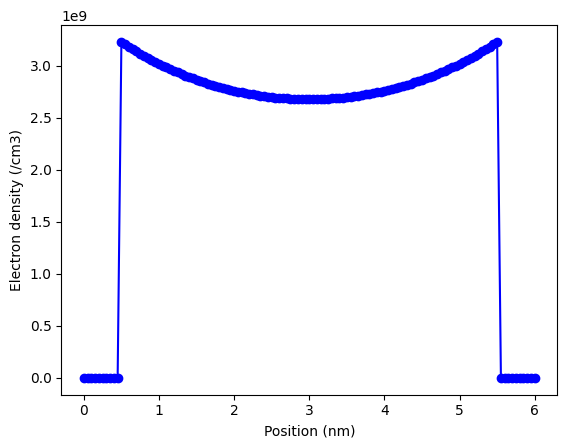

In [23]:
plt.plot(x/1e-9,elec/1e6,'bo-')
plt.xlabel('Position (nm)')
plt.ylabel('Electron density (/cm3)')
plt.show()